In [2]:
# ========================================
# Configurations & Dynamic Deduction
# ========================================
import sys
import os
import argparse

PRJ_PATH = "/home/work/mlp/hslim/LASEF2"

# 1. Check environment & Define Argument Parser
is_jupyter = 'ipykernel' in sys.modules

parser = argparse.ArgumentParser(description="Evaluation runner for SkelLang Multi-Rollouts")
parser.add_argument("--data_dir", type=str, default=None, help="Directory containing dataset files")
parser.add_argument("--model", type=str, default="Qwen2.5-7B-Instruct", help="Model name")
parser.add_argument("--translated", type=str, default="auto", choices=["True", "False", "auto"], help="Translated or Exist")
parser.add_argument("--rollout", type=str, default="auto", choices=["True", "False", "auto"], help="Rollout configuration")
parser.add_argument("--rollout_count", type=str, default="auto", help="Rollout count (integer or 'auto')")

if is_jupyter:
    # Under Jupyter, ignore command-line arguments and load defaults
    args, unknown = parser.parse_known_args(args=[])
else:
    args = parser.parse_args()

MODEL = args.model
FASTTEXT_MODEL_PATH = f"{PRJ_PATH}/lid.176.bin"
SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]
COT_LANGUAGES = ["ta", "kn", "my", "km", "am", "yo", "si", "gu", "ne", "uz", "ky", "ceb", "eu", "gn", "hy", "jv", "ka", "kk", "ku", "lo", "mg", "ml", "mn", "mr", "mt", "or", "pa", "ps", "qu", "sd", "so", "su", "tg", "ug"]

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }

# 2. Smart parameter deduction from directory path
if args.data_dir:
    DATA_DIR = os.path.abspath(args.data_dir)
    folder_name = os.path.basename(os.path.normpath(DATA_DIR))
    
    # Resolve Rollout Count
    if args.rollout_count == "auto":
        if "3_rollout" in folder_name:
            ROLLOUT_COUNT = 3
        elif "5_rollout" in folder_name:
            ROLLOUT_COUNT = 5
        elif "10_rollout" in folder_name:
            ROLLOUT_COUNT = 10
        elif "single_rollout" in folder_name:
            ROLLOUT_COUNT = 1
        elif "translated_skeleton_solved" in folder_name:
            ROLLOUT_COUNT = 1 # default for solved
        elif "translated_skeleton" in folder_name:
            ROLLOUT_COUNT = 1 # default
        else:
            ROLLOUT_COUNT = 5 # default fallback
    else:
        try:
            ROLLOUT_COUNT = int(args.rollout_count)
        except ValueError:
            ROLLOUT_COUNT = 5
            
    # Resolve Rollout True/False
    if args.rollout == "auto":
        ROLLOUT = "single" not in folder_name
    else:
        ROLLOUT = args.rollout == "True"
        
    # Resolve Translated True/False
    if args.translated == "auto":
        TRANSLATED = "exist" not in folder_name.lower()
    else:
        TRANSLATED = args.translated == "True"
else:
    # Under default Jupyter environment, run Exist rollout 10 configuration
    # DATASET = "single_rollout"
    # DATASET = "10_rollout_exist"
    DATASET = "translated_skeleton_solved"
    DATA_DIR = f"{PRJ_PATH}/data/results/SkelLang_MGSM/{DATASET}"
    ROLLOUT_COUNT = 1
    ROLLOUT = False
    TRANSLATED = False

# 3. Define output subdirectory based on active dataset's folder name
if args.data_dir:
    subfolder_name = os.path.basename(os.path.normpath(args.data_dir))
else:
    subfolder_name = DATASET # Default fallback for outputs

SAVE_DIR = f"{PRJ_PATH}/dataframe/{subfolder_name}"
FIG_DIR = f"{PRJ_PATH}/figure/{subfolder_name}"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"========================================================")
print(f"Configuration Loaded:")
print(f"MODEL: {MODEL}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"ROLLOUT_COUNT: {ROLLOUT_COUNT} (ROLLOUT: {ROLLOUT})")
print(f"TRANSLATED: {TRANSLATED}")
print(f"Outputs will be saved in:")
print(f" - CSV: {SAVE_DIR}")
print(f" - Vector plots: {FIG_DIR}")
print(f"========================================================")


Configuration Loaded:
MODEL: Qwen2.5-7B-Instruct
DATA_DIR: /home/work/mlp/hslim/LASEF2/data/results/SkelLang_MGSM/translated_skeleton_solved
ROLLOUT_COUNT: 1 (ROLLOUT: False)
TRANSLATED: False
Outputs will be saved in:
 - CSV: /home/work/mlp/hslim/LASEF2/dataframe/translated_skeleton_solved
 - Vector plots: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved


In [ ]:
# ========================================
# Imports & FastText 로드
# ========================================
import fasttext
import json
import os
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from math_verify import parse, verify
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fasttext.FastText.eprint = lambda x: None
lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
print("FastText model loaded successfully")

In [ ]:
# ========================================
# Helper Functions
# ========================================

from scipy.stats import wilcoxon

def calculate_wilcoxon_pvalue(scores_a, scores_b):
    diffs = [b - a for a, b in zip(scores_a, scores_b)]
    if all(d == 0 for d in diffs):
        return 1.0
    try:
        res = wilcoxon(scores_a, scores_b, zero_method='wilcox')
        return res.pvalue
    except ValueError:
        return 1.0

def detect_language(text):
    global lang_model
    if text is None or not isinstance(text, str):
        return "unk"
    text = text.replace("\n", " ").strip()
    if len(text) < 2:
        return "unk"
    try:
        labels, probs = lang_model.predict(text, k=1)
        if not probs or len(probs) == 0:
            return "unk"
        return labels[0].replace("__label__", "")
    except:
        return "unk"

def load_jsonl(filepath):
    import os, json
    data = []
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except:
                pass
    return data

def add_detected_languages(data, detect_skeleton=False):
    from tqdm import tqdm
    for item in tqdm(data, desc="Detecting languages", leave=False):
        responses = item.get('responses', [])[:ROLLOUT_COUNT]
        item['detected_response_languages'] = [detect_language(r if isinstance(r, str) else "") for r in responses]
        item['detected_response_language'] = item['detected_response_languages'][0] if item['detected_response_languages'] else "unk"
        
        if detect_skeleton:
            skeleton = item.get('skeleton', [])
            skel_text = skeleton[0] if isinstance(skeleton, list) and len(skeleton) > 0 else (skeleton if isinstance(skeleton, str) else "")
            item['detected_skeleton_language'] = detect_language(skel_text)
    return data

def group_by_language(data):
    from collections import defaultdict
    grouped = defaultdict(list)
    for item in data:
        lang = item.get('question_language', 'unknown')
        grouped[lang].append(item)
    return grouped

def evaluate_all_metrics(args):
    example_a, example_b, cot_lang = args
    responses_a = example_a.get('responses', [])[:ROLLOUT_COUNT]
    responses_b = example_b.get('responses', [])[:ROLLOUT_COUNT]
    langs_a = example_a.get('detected_response_languages', [])[:ROLLOUT_COUNT]
    langs_b = example_b.get('detected_response_languages', [])[:ROLLOUT_COUNT]
    
    try:
        from math_verify import parse, verify
        gold = parse(str(example_a['answer']))
        
        scores_strict_a = []
        scores_strict_b = []
        scores_pure_a = []
        scores_pure_b = []
        compliances_a = []
        compliances_b = []
        
        pure_diffs = []
        
        for r in range(min(len(responses_a), len(responses_b))):
            resp_a = responses_a[r]
            resp_b = responses_b[r]
            lang_a = langs_a[r]
            lang_b = langs_b[r]
            
            is_comp_a = (lang_a == cot_lang)
            is_comp_b = (lang_b == cot_lang)
            
            compliances_a.append(1.0 if is_comp_a else 0.0)
            compliances_b.append(1.0 if is_comp_b else 0.0)
            
            try:
                pred_a = parse(str(resp_a))
                correct_a = int(verify(gold, pred_a))
            except:
                correct_a = 0
                
            try:
                pred_b = parse(str(resp_b))
                correct_b = int(verify(gold, pred_b))
            except:
                correct_b = 0
                
            if is_comp_a:
                scores_strict_a.append(correct_a)
                scores_pure_a.append(correct_a)
            else:
                scores_strict_a.append(0)
                
            if is_comp_b:
                scores_strict_b.append(correct_b)
                scores_pure_b.append(correct_b)
            else:
                scores_strict_b.append(0)
                
            if is_comp_a and is_comp_b:
                pure_diffs.append(correct_b - correct_a)
                
        avg_strict_a = sum(scores_strict_a) / len(scores_strict_a) if scores_strict_a else 0.0
        avg_strict_b = sum(scores_strict_b) / len(scores_strict_b) if scores_strict_b else 0.0
        avg_pure_a = sum(scores_pure_a) / len(scores_pure_a) if scores_pure_a else float('nan')
        avg_pure_b = sum(scores_pure_b) / len(scores_pure_b) if scores_pure_b else float('nan')
        avg_comp_a = sum(compliances_a) / len(compliances_a) if compliances_a else 0.0
        avg_comp_b = sum(compliances_b) / len(compliances_b) if compliances_b else 0.0
        
        if pure_diffs:
            pure_delta_i = sum(pure_diffs) / len(pure_diffs)
        else:
            pure_delta_i = float('nan')
            
        return avg_strict_a, avg_strict_b, avg_pure_a, avg_pure_b, avg_comp_a, avg_comp_b, pure_delta_i, 0
    except Exception as e:
        return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), 1

def get_baseline_path(tr, ro, roc):
    import os
    # Priority 1: Direct file pattern matching the folder context
    direct_path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en.jsonl")
    if os.path.exists(direct_path):
        return direct_path
        
    # Priority 2: Fallback to old dynamic suffix patterns
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-en{'_rollout'+str(roc) if ro else ''}_exist.jsonl")
    return path

def get_skellang_path(skel_lang, tr, ro, roc):
    import os
    # Priority 1: Direct file pattern matching the folder context
    direct_path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}.jsonl")
    if os.path.exists(direct_path):
        return direct_path
        
    # Priority 2: Fallback to old dynamic suffix patterns
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}-Google-transQ{'_rollout'+str(roc) if ro else ''}.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL}-skeleton_multiturn_skelLang-{skel_lang}{'_rollout'+str(roc) if ro else ''}_exist.jsonl")
    return path

print("Helper functions updated to 5-rollout multi-metrics with pairwise pure delta formula and smart priority loading.")


In [ ]:
# ========================================
# Baseline 데이터 로드
# ========================================
print("📂 Loading baseline data (English skeleton)...")
baseline_path = get_baseline_path(TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
baseline_data = load_jsonl(baseline_path)

if baseline_data:
    print(f"   Loaded {len(baseline_data)} examples")
    baseline_data = add_detected_languages(baseline_data, detect_skeleton=False)
    baseline_grouped = group_by_language(baseline_data)
    print(f"   Languages: {list(baseline_grouped.keys())}")
else:
    print("❌ Baseline file not found!")

In [ ]:
delta_matrix = defaultdict(dict)
pure_delta_matrix = defaultdict(dict)
accuracy_baseline = defaultdict(dict)
accuracy_target = defaultdict(dict)
sample_counts = defaultdict(dict)
pure_sample_counts = defaultdict(dict)

for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()} ({LANGUAGE_NAMES.get(skel_lang, skel_lang)})")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED, ROLLOUT, ROLLOUT_COUNT)
    target_data = load_jsonl(target_path)
    if target_data is None:
        print(f"   ⚠️ File not found, skipping")
        continue
    print(f"   Loaded {len(target_data)} examples")
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        baseline_lang_data = baseline_grouped.get(cot_lang, [])
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not baseline_lang_data or not target_lang_data:
            print(f"   [{cot_lang}] No data")
            continue
        
        # Align baseline and target samples by unique question ID (original_id or global_id)
        def get_item_id(item):
            orig_id = item.get('original_id')
            if orig_id is None:
                orig_id = item.get('global_id')
            return str(orig_id)
            
        dict_b = {get_item_id(item): item for item in target_lang_data}
        
        aligned_pairs = []
        for item_a in baseline_lang_data:
            key = get_item_id(item_a)
            if key in dict_b:
                aligned_pairs.append((item_a, dict_b[key]))
                
        total_len = len(aligned_pairs)
        
        filtered_pairs = []
        filtered_a, filtered_b, filtered_skel = 0, 0, 0
        
        for item_a, item_b in aligned_pairs:
            langs_a = item_a.get('detected_response_languages', [])
            langs_b = item_b.get('detected_response_languages', [])
            if cot_lang not in langs_a:
                filtered_a += 1
                continue
            if cot_lang not in langs_b:
                filtered_b += 1
                continue
            
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                filtered_skel += 1
                continue
            
            filtered_pairs.append((item_a, item_b))
        
        print(f"   [{cot_lang}] Total matched: {total_len}, A miss: {filtered_a}, B miss: {filtered_b}, Skel miss: {filtered_skel}, Valid: {len(filtered_pairs)}")
        
        if len(filtered_pairs) < 10:
            continue
        
        with Pool(cpu_count()) as pool:
            eval_args = [(a, b, cot_lang) for a, b in filtered_pairs]
            results = list(tqdm(pool.imap(evaluate_all_metrics, eval_args),
                                total=len(eval_args), desc=f"   Eval {cot_lang}", leave=False))
        
        valid_results = [r for r in results if r[7] == 0]
        total = len(valid_results)
        if total == 0: continue
        
        strict_a = [r[0] for r in valid_results]
        strict_b = [r[1] for r in valid_results]
        pure_a = [r[2] for r in valid_results]
        pure_b = [r[3] for r in valid_results]
        comp_a = [r[4] for r in valid_results]
        comp_b = [r[5] for r in valid_results]
        
        pure_delta_is = [r[6] for r in valid_results]
        valid_pure_delta_is = [val for val in pure_delta_is if not np.isnan(val)]
        
        acc_a = sum(strict_a) / total * 100
        acc_b = sum(strict_b) / total * 100
        
        c_rate_a = sum(comp_a) / total * 100
        c_rate_b = sum(comp_b) / total * 100
        
        delta = acc_b - acc_a
        
        if valid_pure_delta_is:
            pure_delta = np.mean(valid_pure_delta_is) * 100
            pure_total = len(valid_pure_delta_is)
        else:
            pure_delta = np.nan
            pure_total = 0
            
        delta_matrix[skel_lang][cot_lang] = delta
        pure_delta_matrix[skel_lang][cot_lang] = pure_delta
        accuracy_baseline[skel_lang][cot_lang] = acc_a
        accuracy_target[skel_lang][cot_lang] = acc_b
        sample_counts[skel_lang][cot_lang] = total
        pure_sample_counts[skel_lang][cot_lang] = pure_total
        
        print(f"   [{cot_lang}] Strict: {acc_a:.1f}%->{acc_b:.1f}% (Δ{delta:+.1f}%) | Pure: Pair-Δ{pure_delta:+.1f}% (N={pure_total}) | Comp: {c_rate_a:.1f}%->{c_rate_b:.1f}%\n")

print("\n✅ Comparison completed!")


In [ ]:
print("\n" + "="*80)
print("📊 Delta Summary (Target - Baseline)")
print("="*80)

header = f"{'Skel Lang':<15}"
for cot_lang in COT_LANGUAGES:
    header += f" {cot_lang.upper():>8}"
header += f" {'AVG':>8}"
print(header)
print("-" * 80)

for skel_lang in SKELETON_LANGUAGES:
    row = f"{skel_lang.upper():<15}"
    deltas = []
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            delta = delta_matrix[skel_lang][cot_lang]
            deltas.append(delta)
            row += f" {delta:>+7.2f}%"
        else:
            row += f" {'N/A':>8}"
    if deltas:
        avg = sum(deltas) / len(deltas)
        row += f" {avg:>+7.2f}%"
    else:
        row += f" {'N/A':>8}"
    print(row)

print("-" * 80)

In [ ]:
df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

# AVG row 강조
avg_idx = df.index.get_loc("AVG")
ax.hlines(y=avg_idx, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
ax.hlines(y=avg_idx + 1, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
for tick in ax.get_yticklabels():
    if tick.get_text() == "AVG":
        tick.set_fontweight("bold")
        tick.set_fontsize(13)
n_cols = df.shape[1]
for text in ax.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
    text.set_fontweight("bold")

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"
SAVE_PATH = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_vertical_unfiltered.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Heatmap saved to: {SAVE_PATH}")
plt.show()


In [ ]:
df_delta = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_pure_delta = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_pure_count = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[skel_lang, cot_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[skel_lang, cot_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[skel_lang, cot_lang] = np.nan
            df_count.loc[skel_lang, cot_lang] = np.nan
            
        if skel_lang in pure_delta_matrix and cot_lang in pure_delta_matrix[skel_lang]:
            df_pure_delta.loc[skel_lang, cot_lang] = pure_delta_matrix[skel_lang][cot_lang]
            df_pure_count.loc[skel_lang, cot_lang] = pure_sample_counts[skel_lang][cot_lang]
        else:
            df_pure_delta.loc[skel_lang, cot_lang] = np.nan
            df_pure_count.loc[skel_lang, cot_lang] = np.nan

annot_combined = np.empty((len(SKELETON_LANGUAGES), len(COT_LANGUAGES)), dtype=object)
annot_pure_combined = np.empty((len(SKELETON_LANGUAGES), len(COT_LANGUAGES)), dtype=object)
for i, skel_lang in enumerate(SKELETON_LANGUAGES):
    for j, cot_lang in enumerate(COT_LANGUAGES):
        delta_val = df_delta.loc[skel_lang, cot_lang]
        pure_delta_val = df_pure_delta.loc[skel_lang, cot_lang]
        count_val = df_count.loc[skel_lang, cot_lang]
        pure_count_val = df_pure_count.loc[skel_lang, cot_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"
            
        if pd.notna(pure_delta_val) and pd.notna(pure_count_val):
            annot_pure_combined[i, j] = f"N={int(pure_count_val)}\n{pure_delta_val:+.1f}%"
        else:
            annot_pure_combined[i, j] = "N/A"

y_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
x_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]
plt.figure(figsize=(14, 7))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 12}
)

plt.title(f"Skeleton Language Strict Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("CoT Language (question_language)", fontsize=12)
plt.ylabel("Skeleton Language", fontsize=12)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Strict Heatmap saved to: {SAVE_PATH2}")
plt.show()

# ----------------- Pure Accuracy Delta Heatmap -----------------
plt.figure(figsize=(14, 7))
ax_pure = sns.heatmap(
    df_pure_delta.astype(float),
    annot=annot_pure_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Pure Accuracy Delta (%)'},
    annot_kws={'fontsize': 12}
)

plt.title(f"Skeleton Language Pure Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("CoT Language (question_language)", fontsize=12)
plt.ylabel("Skeleton Language", fontsize=12)

PURE_SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_pure_delta_heatmap.pdf"
plt.tight_layout()
plt.savefig(PURE_SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Pure Heatmap saved to: {PURE_SAVE_PATH2}")
plt.show()


In [ ]:
df_delta = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_pure_delta = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_pure_count = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[cot_lang, skel_lang] = sample_counts[skel_lang][cot_lang]
        else:
            df_delta.loc[cot_lang, skel_lang] = np.nan
            df_count.loc[cot_lang, skel_lang] = np.nan
            
        if skel_lang in pure_delta_matrix and cot_lang in pure_delta_matrix[skel_lang]:
            df_pure_delta.loc[cot_lang, skel_lang] = pure_delta_matrix[skel_lang][cot_lang]
            df_pure_count.loc[cot_lang, skel_lang] = pure_sample_counts[skel_lang][cot_lang]
        else:
            df_pure_delta.loc[cot_lang, skel_lang] = np.nan
            df_pure_count.loc[cot_lang, skel_lang] = np.nan

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
annot_pure_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        pure_delta_val = df_pure_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        pure_count_val = df_pure_count.loc[cot_lang, skel_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"
            
        if pd.notna(pure_delta_val) and pd.notna(pure_count_val):
            annot_pure_combined[i, j] = f"N={int(pure_count_val)}\n{pure_delta_val:+.1f}%"
        else:
            annot_pure_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 10} 
)

plt.title(f"Skeleton Language Strict Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_vertical.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Strict Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

# ----------------- Pure Accuracy Delta Heatmap (Vertical) -----------------
plt.figure(figsize=(8, 15))
ax_pure = sns.heatmap(
    df_pure_delta.astype(float),
    annot=annot_pure_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Pure Accuracy Delta (%)'},
    annot_kws={'fontsize': 10}
)

plt.title(f"Skeleton Language Pure Performance Delta with Sample Counts\n{MODEL}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

PURE_SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_pure_delta_heatmap_vertical.pdf"
plt.tight_layout()
plt.savefig(PURE_SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Pure Heatmap (Vertical) saved to: {PURE_SAVE_PATH2}")
plt.show()


In [ ]:
dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

delta_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta.csv"
count_path = f"{SAVE_DIR}/{filename_prefix}_strict_count.csv"
pure_delta_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta.csv"
pure_count_path = f"{SAVE_DIR}/{filename_prefix}_pure_count.csv"

df_delta.to_csv(delta_path, index=True)
df_count.to_csv(count_path, index=True)
df_pure_delta.to_csv(pure_delta_path, index=True)
df_pure_count.to_csv(pure_count_path, index=True)


# Exclude languages list
EXCLUDE_LANGS = ["kn", "ku", "jv", "mg", "so", "gn", "uz", "su", "yo", "qu", "ceb", "ka", "tg", "my", "km"]

# Filter out exclude languages (index-wise)
df_delta_filtered = df_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_count_filtered = df_count.drop(index=EXCLUDE_LANGS, errors='ignore')
df_pure_delta_filtered = df_pure_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_pure_count_filtered = df_pure_count.drop(index=EXCLUDE_LANGS, errors='ignore')

# Paths for filtered CSVs
delta_filtered_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta_filtered.csv"
count_filtered_path = f"{SAVE_DIR}/{filename_prefix}_strict_count_filtered.csv"
pure_delta_filtered_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta_filtered.csv"
pure_count_filtered_path = f"{SAVE_DIR}/{filename_prefix}_pure_count_filtered.csv"

# Save filtered CSVs
df_delta_filtered.to_csv(delta_filtered_path, index=True)
df_count_filtered.to_csv(count_filtered_path, index=True)
df_pure_delta_filtered.to_csv(pure_delta_filtered_path, index=True)
df_pure_count_filtered.to_csv(pure_count_filtered_path, index=True)

print(f"✔ strict_delta_filtered / strict_count_filtered CSV 저장 완료: {delta_filtered_path}")
print(f"✔ pure_delta_filtered / pure_count_filtered CSV 저장 완료: {pure_delta_filtered_path}")
print(f"✔ strict_delta / strict_count CSV 저장 완료: {delta_path}")
print(f"✔ pure_delta / pure_count CSV 저장 완료: {pure_delta_path}")


## load csv

Original Count: 34, Filtered Count: 34
✅ Strict Heatmap (Vertical Unfiltered) saved to: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved/Exist_Qwen2.5-7B-Instruct_strict_delta_heatmap_vertical_unfiltered.pdf


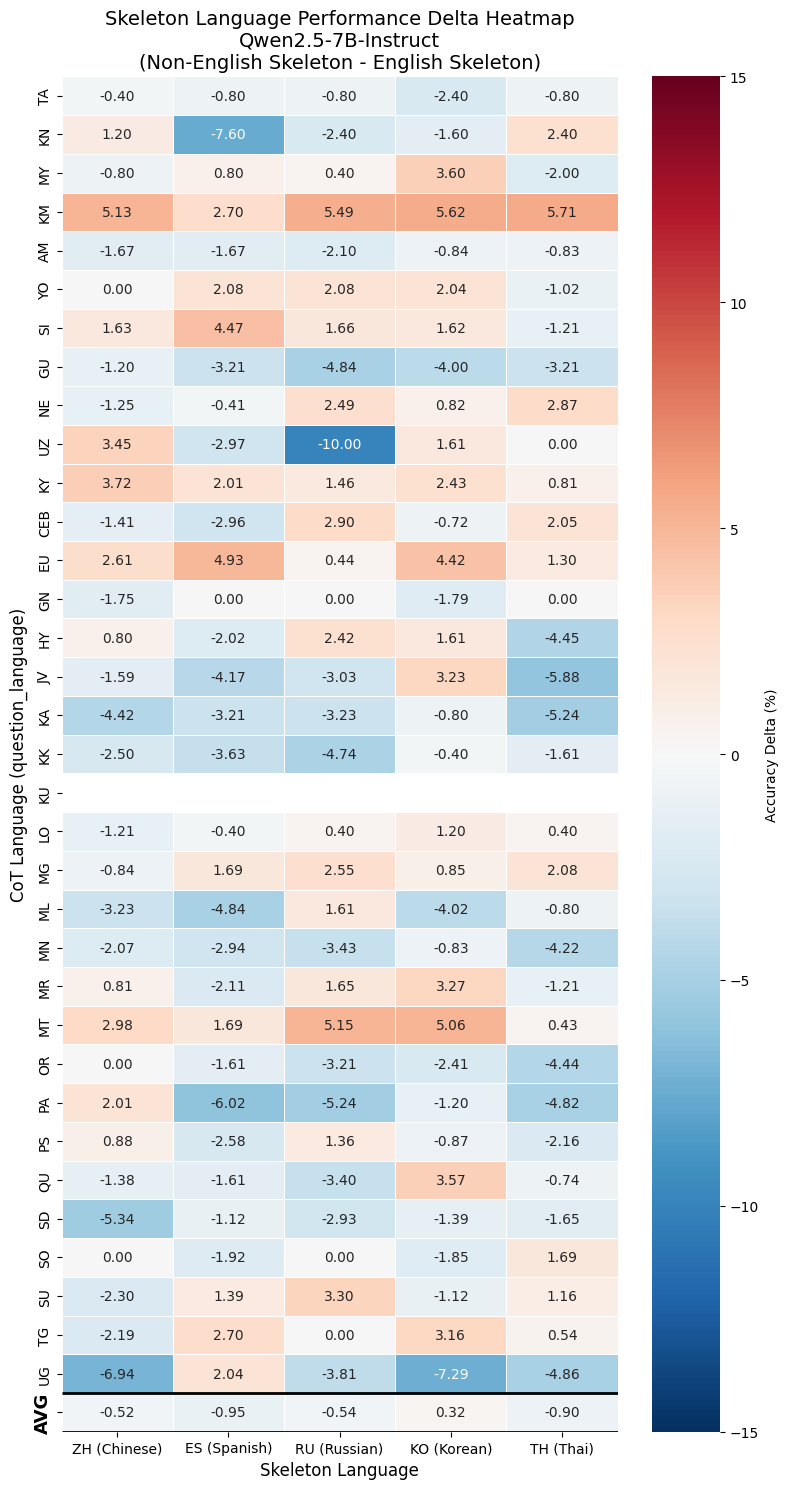

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = globals().get('TRANSLATED', False)
MODEL = globals().get('MODEL', "Qwen2.5-7B-Instruct")
ROLLOUT = globals().get('ROLLOUT', True)
ROLLOUT_COUNT = globals().get('ROLLOUT_COUNT', 5)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}"
# filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

EXCLUDE_LANGS = []

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish", "ru": "Russian",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

data_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta.csv"
if not os.path.exists(data_path):
    print(f"⚠️ Warning: File not found for plotting: {data_path}")
else:
    df_raw = pd.read_csv(data_path, index_col=0)
    delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')
    
    COT_LANGUAGES = delta_matrix.index.tolist()
    SKELETON_LANGUAGES = [lang for lang in SKELETON_LANGUAGES if lang not in EXCLUDE_LANGS]
    
    print(f"Original Count: {len(df_raw)}, Filtered Count: {len(delta_matrix)}")
    
    df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
    for skel_lang in SKELETON_LANGUAGES:
        for cot_lang in COT_LANGUAGES:
            if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
                try:
                    df.loc[cot_lang, skel_lang] = delta_matrix.loc[cot_lang, skel_lang]
                except:
                    df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            else:
                df.loc[cot_lang, skel_lang] = np.nan
                
    x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
    y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]
    
    df.loc["AVG"] = df.mean(axis=0, skipna=True)
    y_labels = [*y_labels, "AVG"]
    
    plt.figure(figsize=(8, 15))
    cmap = sns.diverging_palette(10, 130, as_cmap=True)
    
    ax = sns.heatmap(
        df.astype(float),
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-15,
        vmax=15,
        linewidths=0.5,
        xticklabels=x_labels,
        yticklabels=y_labels,
        cbar_kws={'label': 'Accuracy Delta (%)'}
    )
    
    # AVG row 강조
    avg_idx = df.index.get_loc("AVG")
    ax.hlines(y=avg_idx, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
    ax.hlines(y=avg_idx + 1, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
    for tick in ax.get_yticklabels():
        if tick.get_text() == "AVG":
            tick.set_fontweight("bold")
            tick.set_fontsize(13)
    n_cols = df.shape[1]
    for text in ax.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
        text.set_fontweight("bold")

    plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
    plt.xlabel("Skeleton Language", fontsize=12)
    plt.ylabel("CoT Language (question_language)", fontsize=12)
    
    SAVE_PATH = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_vertical_unfiltered.pdf"
    plt.tight_layout()
    plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
    print(f"✅ Strict Heatmap (Vertical Unfiltered) saved to: {SAVE_PATH}")
    plt.show()


Original Shape: (34, 5)
Filtered Shape: (19, 5)
Excluded: ['kn', 'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
✅ Combined Strict Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved/Exist_Qwen2.5-7B-Instruct_strict_delta_heatmap_vertical_filtered.pdf


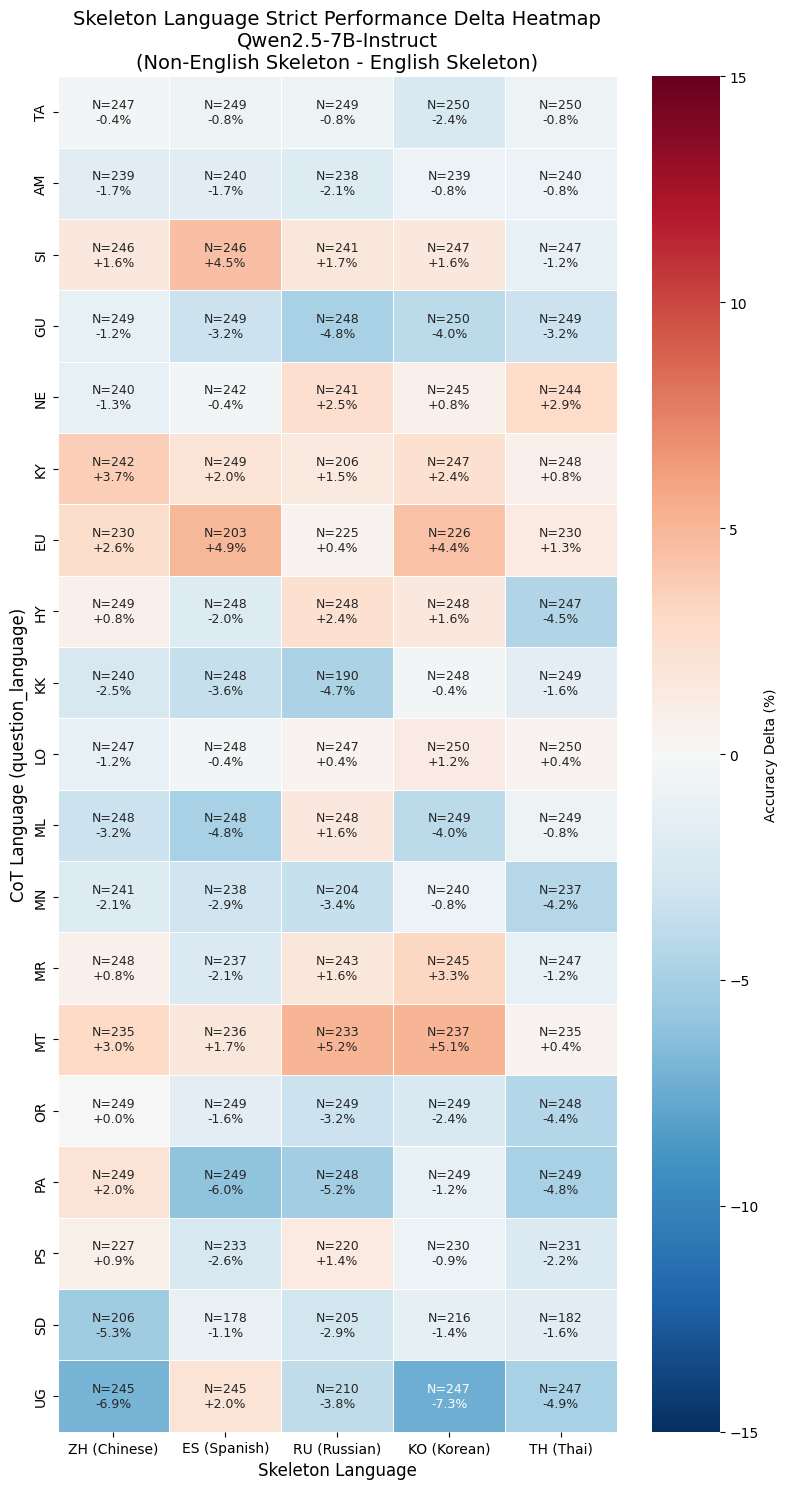

✅ Combined Pure Heatmap (Vertical) saved to: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved/Exist_Qwen2.5-7B-Instruct_pure_delta_heatmap_vertical_filtered.pdf


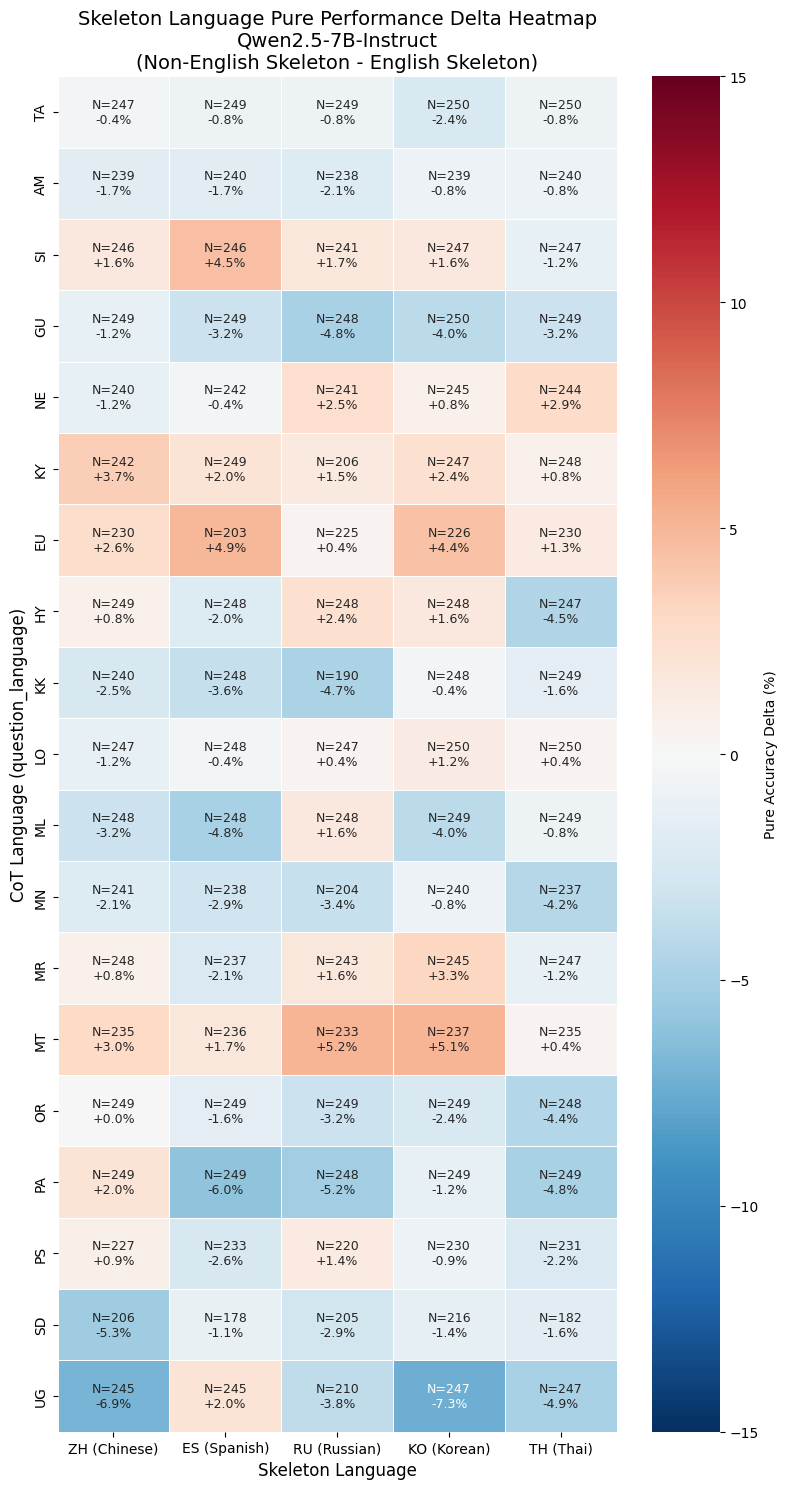

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = globals().get('TRANSLATED', False)
MODEL = globals().get('MODEL', "Qwen2.5-7B-Instruct")
ROLLOUT = globals().get('ROLLOUT', True)
ROLLOUT_COUNT = globals().get('ROLLOUT_COUNT', 5)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}"
# filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

delta_file_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta.csv"
count_file_path = f"{SAVE_DIR}/{filename_prefix}_strict_count.csv"
pure_delta_file_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta.csv"
pure_count_file_path = f"{SAVE_DIR}/{filename_prefix}_pure_count.csv"

df_delta = pd.read_csv(delta_file_path, index_col=0)
df_count = pd.read_csv(count_file_path, index_col=0)
df_pure_delta = pd.read_csv(pure_delta_file_path, index_col=0)
df_pure_count = pd.read_csv(pure_count_file_path, index_col=0)

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']

print(f"Original Shape: {df_delta.shape}")

df_delta = df_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_count = df_count.drop(index=EXCLUDE_LANGS, errors='ignore')
df_pure_delta = df_pure_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_pure_count = df_pure_count.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = df_delta.index.tolist()
SKELETON_LANGUAGES = df_delta.columns.tolist()

print(f"Filtered Shape: {df_delta.shape}")
print(f"Excluded: {EXCLUDE_LANGS}")

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
annot_pure_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)

for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        pure_delta_val = df_pure_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        pure_count_val = df_pure_count.loc[cot_lang, skel_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"
            
        if pd.notna(pure_delta_val) and pd.notna(pure_count_val):
            annot_pure_combined[i, j] = f"N={int(pure_count_val)}\n{pure_delta_val:+.1f}%"
        else:
            annot_pure_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" if 'LANGUAGE_NAMES' in globals() else lang.upper() for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

plt.figure(figsize=(8, 15))
cmap = plt.get_cmap("RdBu_r")

ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 9}
)

plt.title(f"Skeleton Language Strict Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel('CoT Language (question_language)', fontsize=12)

SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_vertical_filtered.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Strict Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

# ----------------- Pure Accuracy Delta Heatmap (Vertical, Filtered) -----------------
plt.figure(figsize=(8, 15))
ax_pure = sns.heatmap(
    df_pure_delta.astype(float),
    annot=annot_pure_combined,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Pure Accuracy Delta (%)'},
    annot_kws={'fontsize': 9}
)

plt.title(f"Skeleton Language Pure Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

PURE_SAVE_PATH2 = f"{FIG_DIR}/{filename_prefix}_pure_delta_heatmap_vertical_filtered.pdf"

plt.tight_layout()
plt.savefig(PURE_SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Pure Heatmap (Vertical) saved to: {PURE_SAVE_PATH2}")
plt.show()


Sorted COT Languages: ['kk', 'ky', 'mn', 'ug', 'hy', 'lo', 'eu', 'mt', 'am', 'ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
✅ Sorted Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved/Exist_Qwen2.5-7B-Instruct_strict_delta_heatmap_sorted.pdf


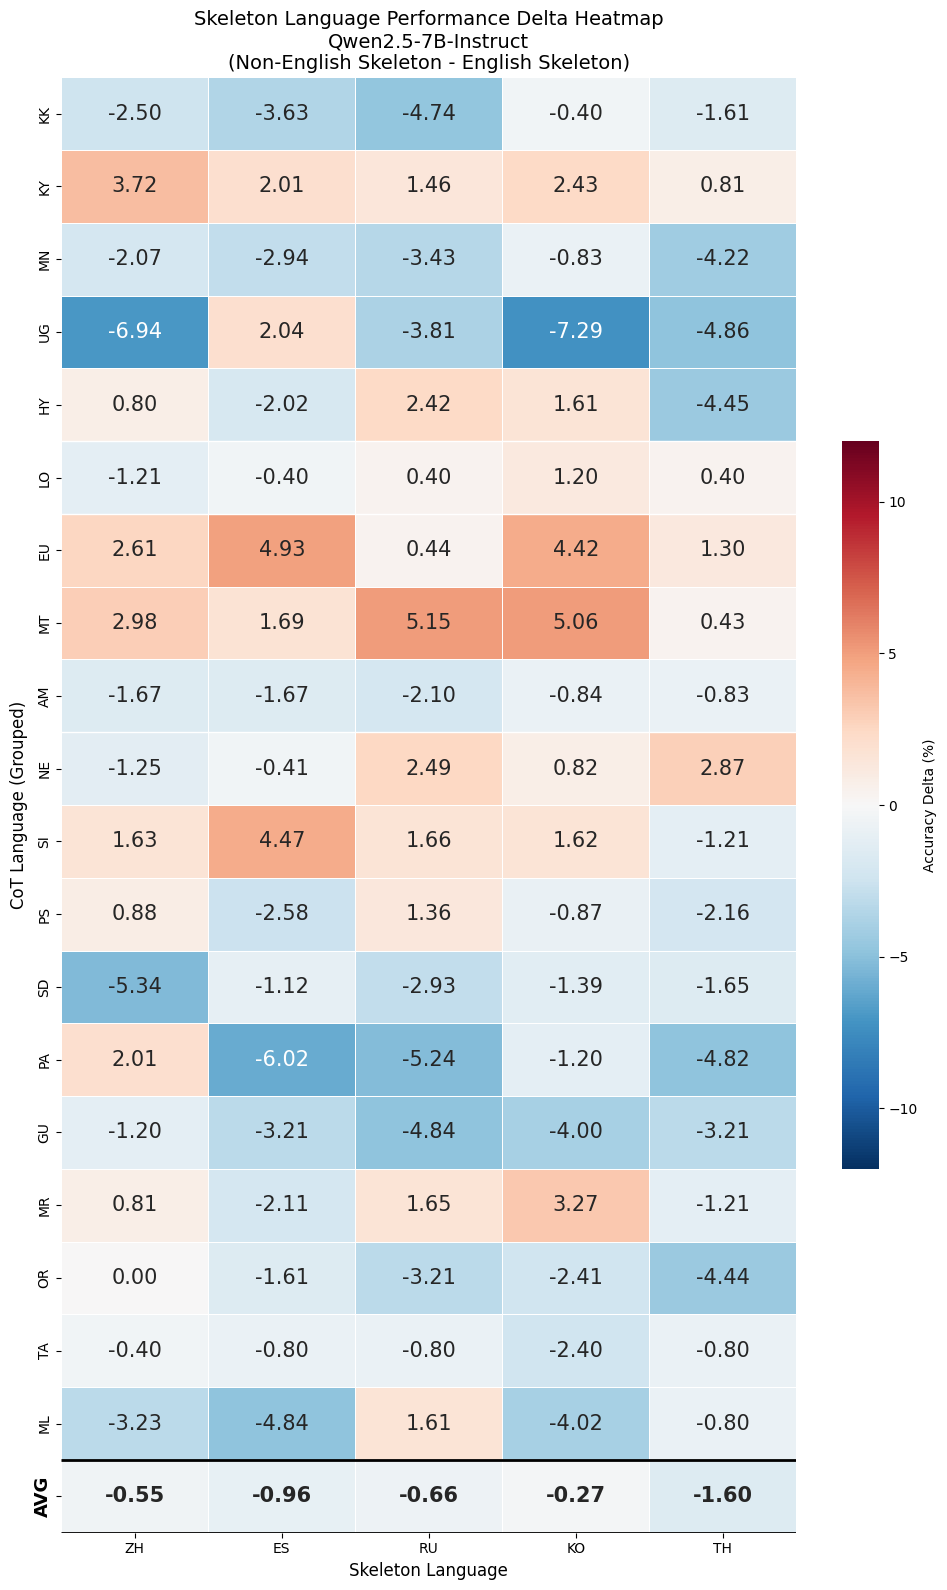

✅ Sorted Pure Heatmap saved to: /home/work/mlp/hslim/LASEF2/figure/translated_skeleton_solved/Exist_Qwen2.5-7B-Instruct_pure_delta_heatmap_sorted.pdf


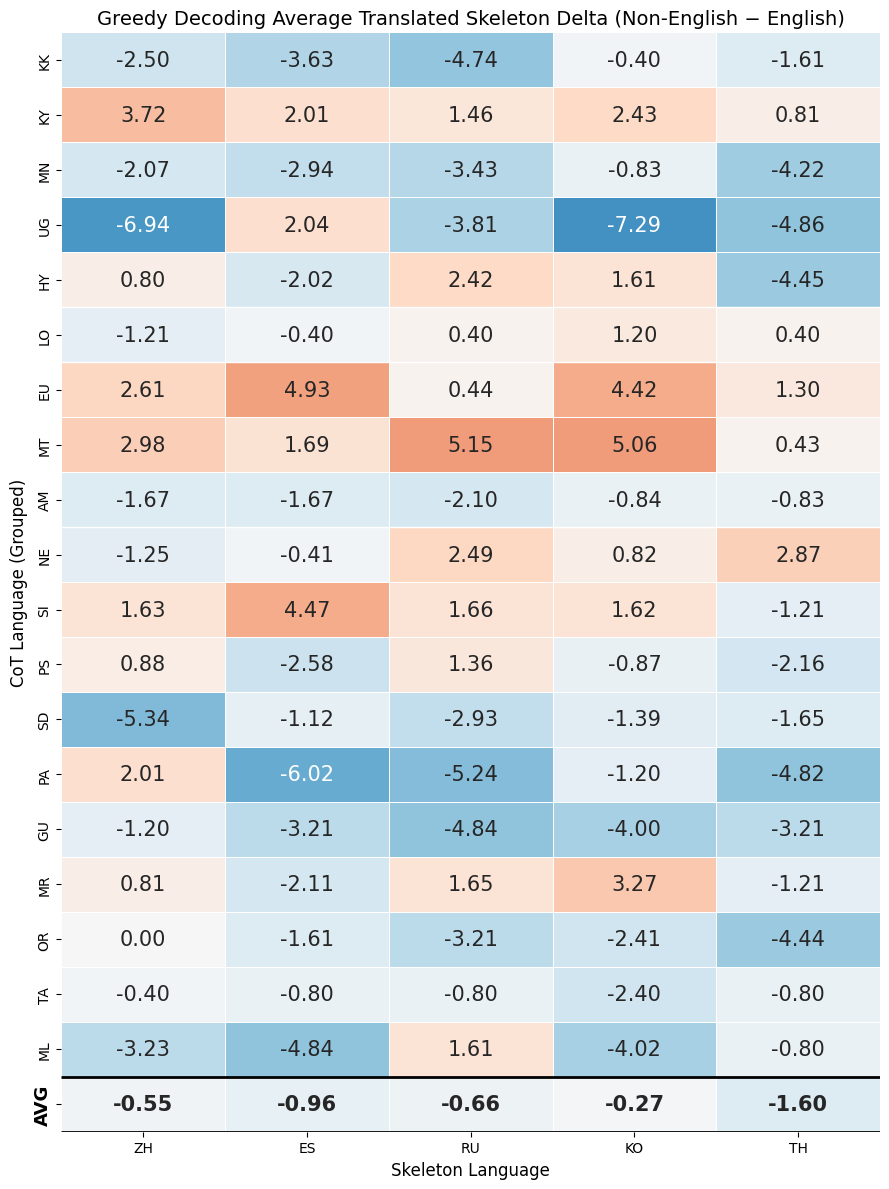

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = globals().get('TRANSLATED', False)
MODEL = globals().get('MODEL', "Qwen2.5-7B-Instruct")
ROLLOUT = globals().get('ROLLOUT', True)
ROLLOUT_COUNT = globals().get('ROLLOUT_COUNT', 5)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}"
# filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur"
    }

data_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta.csv"
pure_data_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta.csv"

df_raw = pd.read_csv(data_path, index_col=0)
df_pure_raw = pd.read_csv(pure_data_path, index_col=0)

SORT_ORDER_GROUPS = {
    "Cyrillic/Post-Soviet": ['kk', 'ky', 'mn', 'ug', 'hy'],
    "SE Asia (Thai/Pali)": ['lo', 'km', 'my'],
    "Euro/Misc": ['eu', 'mt', 'am'],
    "Indo-Subcontinent": ['ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
}

DESIRED_ORDER = []
for group in SORT_ORDER_GROUPS.values():
    DESIRED_ORDER.extend(group)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')
pure_delta_matrix_filtered = df_pure_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

available_langs = delta_matrix.index.tolist()
sorted_langs = [lang for lang in DESIRED_ORDER if lang in available_langs]
remaining_langs = [lang for lang in available_langs if lang not in sorted_langs]

FINAL_COT_ORDER = sorted_langs + remaining_langs
COT_LANGUAGES = FINAL_COT_ORDER

print(f"Sorted COT Languages: {COT_LANGUAGES}")

df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_pure = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
             try:
                df.loc[cot_lang, skel_lang] = delta_matrix.loc[cot_lang, skel_lang]
             except:
                df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan
            
        if skel_lang in pure_delta_matrix_filtered and cot_lang in pure_delta_matrix_filtered[skel_lang]:
             try:
                df_pure.loc[cot_lang, skel_lang] = pure_delta_matrix_filtered.loc[cot_lang, skel_lang]
             except:
                df_pure.loc[cot_lang, skel_lang] = pure_delta_matrix_filtered[skel_lang][cot_lang]
        else:
            df_pure.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()}" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
df_pure.loc["AVG"] = df_pure.mean(axis=0, skipna=True)
y_labels_final = [*y_labels, "AVG"]

plt.figure(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15},
    cmap="RdBu_r",
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels_final,
    cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5}
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for lang in langs if lang in COT_LANGUAGES)
    if count > 0:
        current_idx += count
        ax.hlines(current_idx, *ax.get_xlim(), colors='white', linewidth=1)

# AVG row 강조
avg_idx = df.index.get_loc("AVG")
ax.hlines(y=avg_idx, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
ax.hlines(y=avg_idx + 1, xmin=0, xmax=df.shape[1], colors="black", linewidth=2.0)
for tick in ax.get_yticklabels():
    if tick.get_text() == "AVG":
        tick.set_fontweight("bold")
        tick.set_fontsize(13)
n_cols = df.shape[1]
for text in ax.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
    text.set_fontweight("bold")

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)

SAVE_PATH = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_sorted.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Heatmap saved to: {SAVE_PATH}")
plt.show()

# ----------------- Pure Accuracy Delta Sorted Heatmap (Vertical) -----------------
plt.figure(figsize=(9, 12))
ax_pure = sns.heatmap(
    df_pure.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15},
    cmap="RdBu_r",
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels_final,
    cbar_kws={'label': 'Pure Accuracy Delta (%)', 'shrink': 0.5},
    cbar=False
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for lang in langs if lang in COT_LANGUAGES)
    if count > 0:
        current_idx += count
        ax_pure.hlines(current_idx, *ax_pure.get_xlim(), colors='white', linewidth=1)

# AVG row 강조
avg_idx = df_pure.index.get_loc("AVG")
ax_pure.hlines(y=avg_idx, xmin=0, xmax=df_pure.shape[1], colors="black", linewidth=2.0)
ax_pure.hlines(y=avg_idx + 1, xmin=0, xmax=df_pure.shape[1], colors="black", linewidth=2.0)
for tick in ax_pure.get_yticklabels():
    if tick.get_text() == "AVG":
        tick.set_fontweight("bold")
        tick.set_fontsize(13)
n_cols = df_pure.shape[1]
for text in ax_pure.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
    text.set_fontweight("bold")

# plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.title(
    f"Greedy Decoding Average Translated Skeleton Delta (Non-English − English)",
    # f"Greedy Decoding Average Skeleton Delta (Non-English − English)",
    # f"5-Rollout Average Skeleton Delta (Non-English − English)",
    fontsize=14
)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)

PURE_SAVE_PATH = f"{FIG_DIR}/{filename_prefix}_pure_delta_heatmap_sorted.pdf"

plt.tight_layout()
plt.savefig(PURE_SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Pure Heatmap saved to: {PURE_SAVE_PATH}")
plt.show()


In [ ]:
# =========================================================
# 📊 10 Languages Performance Delta Analysis
# =========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = globals().get('TRANSLATED', False)
MODEL = globals().get('MODEL', "Qwen2.5-7B-Instruct")
ROLLOUT = globals().get('ROLLOUT', True)
ROLLOUT_COUNT = globals().get('ROLLOUT_COUNT', 5)

dataset_type = "TransQ" if TRANSLATED else "Exist"
rollout_str = f"rollout{ROLLOUT_COUNT}" if ROLLOUT else "single"
filename_prefix = f"{dataset_type}_{MODEL}_{rollout_str}"

# User specified 10 languages
SELECTED_LANGS = ['hy', 'lo', 'eu', 'mt', 'mn', 'ug', 'kk', 'am', 'ml', 'ta']

# Group ordering for visual coherence
SORT_ORDER_GROUPS_10 = {
    "Consistent positive": ['hy', 'lo', 'eu'],
    "Quality-dependent": ['mt'],
    "Asymmetric/Mixed": ['mn', 'ug', 'kk', 'am'],
    "Stable negative": ['ml', 'ta']
}

data_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta.csv"
pure_data_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta.csv"

df_raw = pd.read_csv(data_path, index_col=0)
df_pure_raw = pd.read_csv(pure_data_path, index_col=0)

DESIRED_ORDER_10 = []
for group in SORT_ORDER_GROUPS_10.values():
    DESIRED_ORDER_10.extend(group)

# Extract and sort 10 languages
available_langs_10 = [lang for lang in DESIRED_ORDER_10 if lang in df_raw.index]

df_10 = df_raw.loc[available_langs_10].copy()
df_pure_10 = df_pure_raw.loc[available_langs_10].copy()

count_data_path = f"{SAVE_DIR}/{filename_prefix}_strict_count.csv"
pure_count_data_path = f"{SAVE_DIR}/{filename_prefix}_pure_count.csv"

df_count_raw = pd.read_csv(count_data_path, index_col=0)
df_pure_count_raw = pd.read_csv(pure_count_data_path, index_col=0)

df_count_10 = df_count_raw.loc[available_langs_10].copy()
df_pure_count_10 = df_pure_count_raw.loc[available_langs_10].copy()

# Calculate AVG row
df_10.loc["AVG"] = df_10.mean(axis=0, skipna=True)
df_pure_10.loc["AVG"] = df_pure_10.mean(axis=0, skipna=True)
df_count_10.loc["AVG"] = df_count_10.mean(axis=0, skipna=True)
df_pure_count_10.loc["AVG"] = df_pure_count_10.mean(axis=0, skipna=True)

y_labels_10 = [f"{lang.upper()}" for lang in available_langs_10] + ["AVG"]
x_labels_10 = [f"{lang.upper()}" for lang in df_10.columns]

# ----------------- Save 10 Languages CSVs -----------------
delta_10_path = f"{SAVE_DIR}/{filename_prefix}_strict_delta_10langs.csv"
pure_delta_10_path = f"{SAVE_DIR}/{filename_prefix}_pure_delta_10langs.csv"
count_10_path = f"{SAVE_DIR}/{filename_prefix}_strict_count_10langs.csv"
pure_count_10_path = f"{SAVE_DIR}/{filename_prefix}_pure_count_10langs.csv"

df_10.to_csv(delta_10_path, index=True)
df_pure_10.to_csv(pure_delta_10_path, index=True)
df_count_10.to_csv(count_10_path, index=True)
df_pure_count_10.to_csv(pure_count_10_path, index=True)
print(f"✔ strict_delta_10langs CSV 저장 완료: {delta_10_path}")
print(f"✔ pure_delta_10langs CSV 저장 완료: {pure_delta_10_path}")
print(f"✔ strict_count_10langs CSV 저장 완료: {count_10_path}")
print(f"✔ pure_count_10langs CSV 저장 완료: {pure_count_10_path}")

# ----------------- Plot 10 Languages Strict Heatmap -----------------
plt.figure(figsize=(10, 12))
ax_10 = sns.heatmap(
    df_10.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15},
    cmap="RdBu_r",
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels_10,
    yticklabels=y_labels_10,
    cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5}
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS_10.items():
    count = sum(1 for lang in langs if lang in available_langs_10)
    if count > 0:
        current_idx += count
        ax_10.hlines(current_idx, *ax_10.get_xlim(), colors='white', linewidth=1)

# AVG row 강조
avg_idx = df_10.index.get_loc("AVG")
ax_10.hlines(y=avg_idx, xmin=0, xmax=df_10.shape[1], colors="black", linewidth=2.0)
ax_10.hlines(y=avg_idx + 1, xmin=0, xmax=df_10.shape[1], colors="black", linewidth=2.0)
for tick in ax_10.get_yticklabels():
    if tick.get_text() == "AVG":
        tick.set_fontweight("bold")
        tick.set_fontsize(13)
n_cols = df_10.shape[1]
for text in ax_10.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
    text.set_fontweight("bold")

plt.title(f"Skeleton Language Performance Delta Heatmap (10 Languages)\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped - 10 Languages)", fontsize=12)

SAVE_PATH_10 = f"{FIG_DIR}/{filename_prefix}_strict_delta_heatmap_sorted_10langs.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH_10, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Heatmap (10 Languages) saved to: {SAVE_PATH_10}")
plt.show()

# ----------------- Plot 10 Languages Pure Heatmap -----------------
plt.figure(figsize=(10, 12))
ax_pure_10 = sns.heatmap(
    df_pure_10.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15},
    cmap="RdBu_r",
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels_10,
    yticklabels=y_labels_10,
    cbar_kws={'label': 'Pure Accuracy Delta (%)', 'shrink': 0.5}
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS_10.items():
    count = sum(1 for lang in langs if lang in available_langs_10)
    if count > 0:
        current_idx += count
        ax_pure_10.hlines(current_idx, *ax_pure_10.get_xlim(), colors='white', linewidth=1)

# AVG row 강조
avg_idx = df_pure_10.index.get_loc("AVG")
ax_pure_10.hlines(y=avg_idx, xmin=0, xmax=df_pure_10.shape[1], colors="black", linewidth=2.0)
ax_pure_10.hlines(y=avg_idx + 1, xmin=0, xmax=df_pure_10.shape[1], colors="black", linewidth=2.0)
for tick in ax_pure_10.get_yticklabels():
    if tick.get_text() == "AVG":
        tick.set_fontweight("bold")
        tick.set_fontsize(13)
n_cols = df_pure_10.shape[1]
for text in ax_pure_10.texts[avg_idx * n_cols : (avg_idx + 1) * n_cols]:
    text.set_fontweight("bold")

plt.title(f"Skeleton Language Pure Performance Delta Heatmap (10 Languages)\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped - 10 Languages)", fontsize=12)

PURE_SAVE_PATH_10 = f"{FIG_DIR}/{filename_prefix}_pure_delta_heatmap_sorted_10langs.pdf"
plt.tight_layout()
plt.savefig(PURE_SAVE_PATH_10, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Pure Heatmap (10 Languages) saved to: {PURE_SAVE_PATH_10}")
plt.show()


In [ ]:
df